Import Libraries

In [152]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 

PART 1: Ensemble Learning

Load Iris Dataset

In [153]:
# Load dataset
iris = load_iris()

# Create a DataFrame using the data and feature names
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target (if needed)
df['target'] = iris.target

# Show dataset
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


Visualize Data

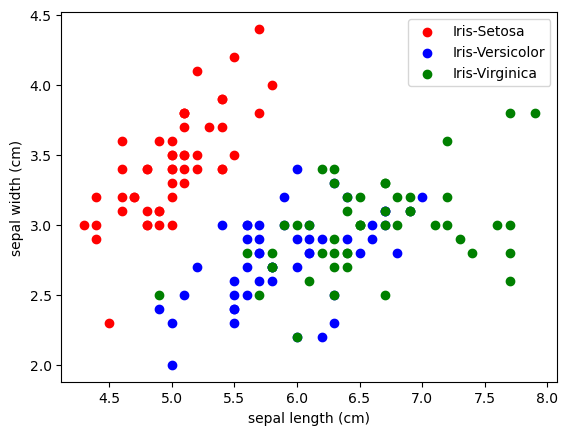

In [154]:
colors = ['red', 'blue', 'green']
species = [0, 1, 2]
label_data = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

for i in range (3):
    x = df[df['target'] == species[i]]  # Collect all rows whose targets = species[i]
    pyplot.scatter(x['sepal length (cm)'], x['sepal width (cm)'], c = colors[i], label=label_data[i])

pyplot.xlabel('sepal length (cm)')
pyplot.ylabel('sepal width (cm)')
pyplot.legend()

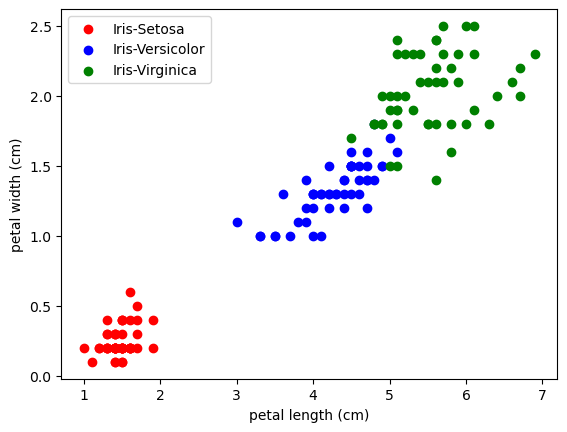

In [155]:
colors = ['red', 'blue', 'green']
species = [0, 1, 2]
label_data = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

for i in range (3):
    x = df[df['target'] == species[i]]  # Collect all rows whose targets = species[i]
    pyplot.scatter(x['petal length (cm)'], x['petal width (cm)'], c = colors[i], label=label_data[i])

pyplot.xlabel('petal length (cm)')
pyplot.ylabel('petal width (cm)')
pyplot.legend()

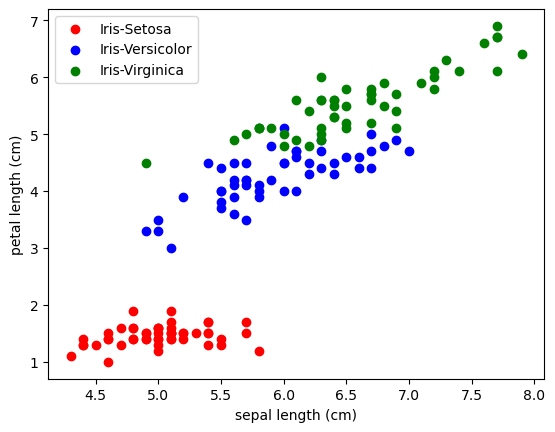

In [156]:
colors = ['red', 'blue', 'green']
species = [0, 1, 2]
label_data = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

for i in range (3):
    x = df[df['target'] == species[i]]  # Collect all rows whose targets = species[i]
    pyplot.scatter(x['sepal length (cm)'], x['petal length (cm)'], c = colors[i], label=label_data[i])

pyplot.xlabel('sepal length (cm)')
pyplot.ylabel('petal length (cm)')
pyplot.legend()

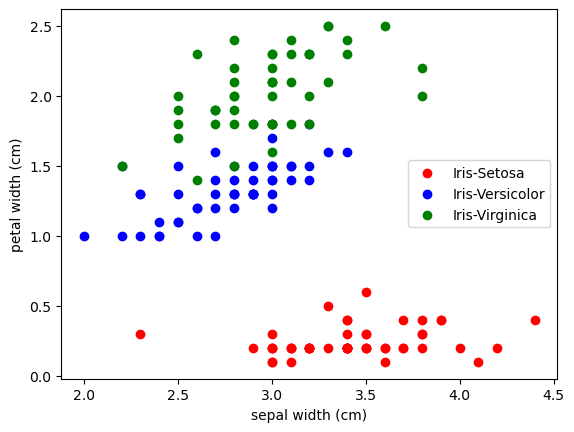

In [157]:
colors = ['red', 'blue', 'green']
species = [0, 1, 2]
label_data = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

for i in range (3):
    x = df[df['target'] == species[i]]  # Collect all rows whose targets = species[i]
    pyplot.scatter(x['sepal width (cm)'], x['petal width (cm)'], c = colors[i], label=label_data[i])

pyplot.xlabel('sepal width (cm)')
pyplot.ylabel('petal width (cm)')
pyplot.legend()

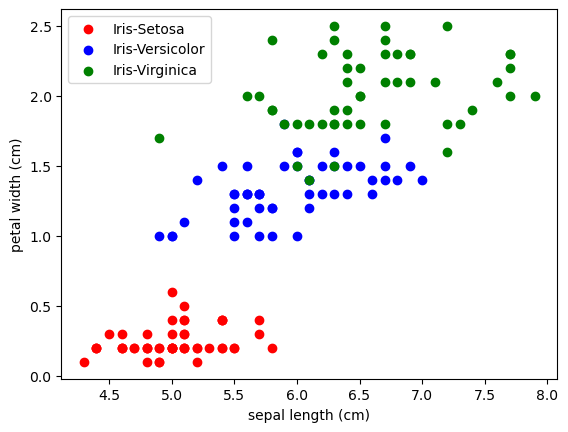

In [158]:
colors = ['red', 'blue', 'green']
species = [0, 1, 2]
label_data = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

for i in range (3):
    x = df[df['target'] == species[i]]  # Collect all rows whose targets = species[i]
    pyplot.scatter(x['sepal length (cm)'], x['petal width (cm)'], c = colors[i], label=label_data[i])

pyplot.xlabel('sepal length (cm)')
pyplot.ylabel('petal width (cm)')
pyplot.legend()

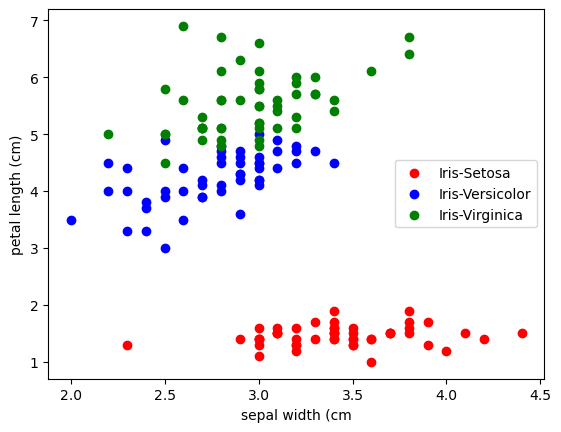

In [159]:
colors = ['red', 'blue', 'green']
species = [0, 1, 2]
label_data = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

for i in range (3):
    x = df[df['target'] == species[i]]  # Collect all rows whose targets = species[i]
    pyplot.scatter(x['sepal width (cm)'], x['petal length (cm)'], c = colors[i], label=label_data[i])

pyplot.xlabel('sepal width (cm')
pyplot.ylabel('petal length (cm)')
pyplot.legend()

Divide dataset into training set and test set

In [160]:
X = iris.data[iris.target != 0]     
Y = iris.target[iris.target != 0]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

1. Support Vector Machine (SVM)

In [161]:
from sklearn.svm import SVC
model1 = SVC(probability=True)

# Train Model 
model1.fit(X_train, y_train)

# Evaluate Model
score = model1.score(X_test, y_test)
print(f'SVM Score: {score}')

SVM Score: 0.95


2. Logistic Regression

In [162]:
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression()

# Train Model 
model2.fit(X_train, y_train)

# Evaluate Model
score = model2.score(X_test, y_test)
print(f'Logistic Regression Score: {score}')

Logistic Regression Score: 0.95


3. K-Nearest Neighbour 

In [163]:
from sklearn.neighbors import KNeighborsClassifier
model3 = KNeighborsClassifier()
# Train Model 
model3.fit(X_train, y_train)

# Evaluate Model
score = model3.score(X_test, y_test)
print(f'K-Nearest Neighbour Score: {score}')

K-Nearest Neighbour Score: 0.9


4. Voting

In [164]:
from sklearn.ensemble import VotingClassifier
voting_classfier = VotingClassifier(estimators=[('svm', model1), 
                                                ('logreg', model2), 
                                                ('knn', model3)],
                                                voting='hard'  # 'hard' for majority voting, 'soft' for weighted voting
                                   )

# Train Model 
voting_classfier.fit(X_train, y_train)

# Evaluate Model
score = voting_classfier.score(X_test, y_test)
print(f'Voting Score: {score}')

Voting Score: 0.95


Question. Compare the performance of voting classifier with that of individual classifier.<br>
Answer: The performance of the voting classifier (score = 0.95) is the same as that of SVM and Logistic Regression.<br> 
On the other hand, the performance of the voting classifier (score = 0.95) us much better than that of K-Nearest Neighbour (score = 0.9) 

PART 2: Perceptron

In [165]:
from sklearn.linear_model import Perceptron
perceptron_classifier = Perceptron()

# Train Model 
perceptron_classifier.fit(X_train, y_train)

# Evaluate Model
score = perceptron_classifier.score(X_test, y_test)
print(f'Perceptron Score: {score}')

Perceptron Score: 0.9


Question. Compare the performance of perceptron classifier with the ensemble class performance.<br>
Answer: The performance of the perceptron classifier (score = 0.9) is not good as that of voting classifier (score = 0.95)